# Uncertainty Words — do hedgy filings mean a volatility spike? 🤔
### Counting how often bosses say 'uncertain', 'maybe', 'could' — and what happens next

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

When a company files its annual report or holds an earnings call, someone can *count the hedging words* — 'uncertain', 'maybe', 'could', 'risk', 'approximately', 'depend'. A famous 2011 study (Loughran & McDonald) built the finance dictionary for exactly this and found that filings stuffed with uncertainty words are followed by **more volatility** — and, more weakly, **lower returns**. The idea: hedgy language flags that even management isn't sure, and that ambiguity shows up as a jumpier stock.

Sounds clean. But there's a trap, and this notebook is really about the trap.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice**, and note: **there is no free data feed** of scored filings joined to future volatility, so everything below runs on a *simulated* world where we *plant* the effect on purpose — to show how the machinery behaves and where it can fool you. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from uncertainty_word_count import data, strategy as st

# This study is SYNTHETIC-ONLY: no free feed of scored filings joined to forward vol exists, so
# fetch_panel() is a documented stub returning an empty frame. Every figure below runs on the
# deterministic, seeded synthetic panel -- offline, reproducible, and NEVER labelled as a real tape.
REAL = data.fetch_panel(fetch=False)
HAVE_REAL = not REAL.empty
print("real tape present:", HAVE_REAL, "(synthetic-only study -- expected False)")

PANEL, TRUTH = data.synthetic_panel()          # seed 567, planted uncert_beta=0.020
print("synthetic panel:", len(PANEL), "firm-events,", PANEL['ticker'].nunique(),
      "firms x", PANEL['period'].nunique(), "periods | fp", data.fingerprint(PANEL))


real tape present: False (synthetic-only study -- expected False)
synthetic panel: 480 firm-events, 40 firms x 12 periods | fp fa07e8ea11c3


## The answer first 🎯

| Question | Answer |
|---|---|
| Do hedgy filings *look* like they predict volatility? | **Yes, hugely** — the raw link is enormous (a *t*-stat of **13.41**). |
| Is that link real? | **Mostly not.** The firms that write hedgy filings are the firms that were *already jumpy*. Once you account for that, the link shrinks from *t* **13.41** to *t* **3.3**. Two-thirds of it was an illusion. |
| So is there *any* real edge? | **In this simulation, a small one** — but we can't check it on real data, because no free feed of scored filings + future volatility exists. |
| Could you trade it? | **Barely.** The signal only comes ~4×/year and its strength swings a lot from quarter to quarter. |

> The lesson isn't 'uncertainty words are useless' — it's that the *obvious* version of the signal is mostly a **confound**: uncertain companies were already volatile. You have to subtract that out before you believe the words.

## 1 · The claim

> *"The more uncertainty / hedging words a firm uses, the higher its future volatility and the lower its future returns."* — Loughran & McDonald (2011); Campbell et al. (2014); Kravet & Muslu (2013).

The intuition: language leaks information. If management litters a filing with 'may', 'could', 'risk', 'uncertain', they're signalling — maybe unconsciously — that the future is foggy. Foggy futures resolve as *volatility*. And nervous investors might demand a discount, dragging returns down. It's one of the founding results of finance text mining.

## 2 · So what?

If it's real and clean, you could read a 10-K, count the hedges, and *forecast the stock's risk* before the market fully prices it — useful for options, position sizing, and a long-plain / short-hedgy trade. The desk has looked at the *sentiment* side of text before ([566 earnings-call-tone](../../566-earnings-call-tone/) scores upbeat-vs-guarded tone against **drift**); here we go after a *different* dictionary — the **uncertainty** list — and a *different* outcome — **volatility**.

## 3 · How would we even know?

1. **Score each filing.** Count the share of words that are hedges (the uncertainty density).
2. **Wait.** Measure the stock's volatility over the *next* window (never peeking — the score is known at the filing, the volatility comes after).
3. **Relate them.** Do hedgier filings come before jumpier stocks?

**The catch — and the whole point.** Companies that are *already* volatile tend to write hedgier filings (they have more to hedge about), and volatility is *sticky* — a jumpy stock stays jumpy. So hedgy-filing → future-vol could be almost entirely 'jumpy stocks stay jumpy', with the words adding nothing. We *must* subtract out how jumpy each firm already was before we credit the words.

> Because no free feed of scored filings exists, we build a **simulated** world where we control the truth: we plant a real (but modest) words→vol link *on top of* the 'jumpy-stays-jumpy' stickiness, then see whether our test can tell them apart.

## 4 · The teardown — the confound in one picture

Here's the trap, drawn. The **naive** number ignores how jumpy each firm already was; the **honest** number subtracts it out first.

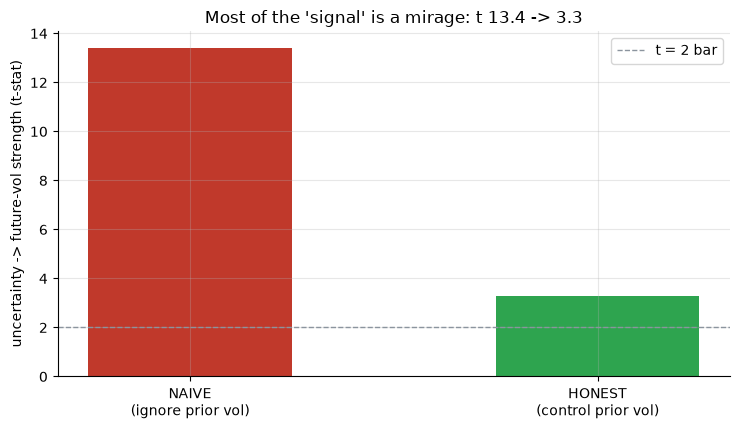

naive t 13.41  ->  honest (controlled) t 3.30


In [2]:
naive = st.uncertainty_vol_regression(PANEL, control_trail_vol=False)
ctrl  = st.uncertainty_vol_regression(PANEL, control_trail_vol=True)
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['NAIVE\n(ignore prior vol)', 'HONEST\n(control prior vol)'],
       [naive['uncert_t'], ctrl['uncert_t']], color=[RED, GREEN], width=.5)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.set_ylabel('uncertainty -> future-vol strength (t-stat)')
ax.set_title(f"Most of the 'signal' is a mirage: t {naive['uncert_t']:.1f} -> {ctrl['uncert_t']:.1f}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"naive t {naive['uncert_t']:.2f}  ->  honest (controlled) t {ctrl['uncert_t']:.2f}")

There it is. The raw link between hedgy filings and future volatility is a monster (*t* **13.41**). But once we subtract out **how volatile each firm already was**, it collapses to *t* **3.3**. About two-thirds of the apparent signal was just *jumpy stocks stay jumpy* — nothing to do with the words. The surviving piece (the planted textual edge) is real *in this simulation*, but it's a fraction of what the naive number screamed.

**Does the surviving edge hold up quarter to quarter?** Split the periods into four chunks and re-measure the honest link in each:

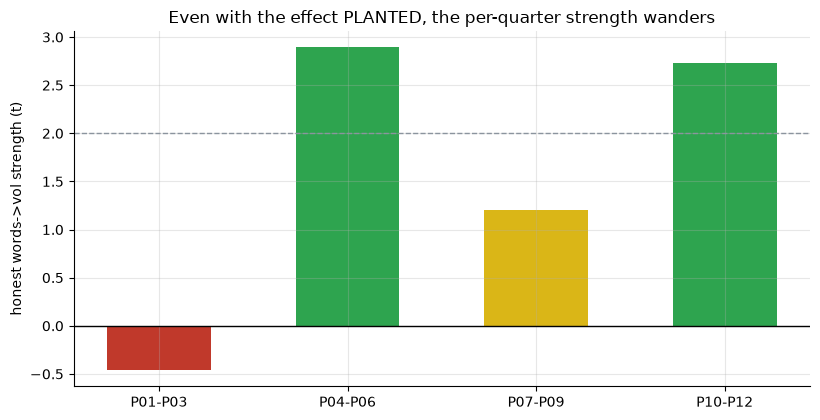

per-window t: [-0.46, 2.89, 1.2, 2.73]


In [3]:
rows = st.robustness_windows(PANEL, 4)
labs = [r[0] for r in rows]; ts = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(8.3, 4.3))
cols = [GREEN if t >= 2 else (AMBER if t > 0 else RED) for t in ts]
ax.bar(labs, ts, color=cols, width=.55)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('honest words->vol strength (t)')
ax.set_title('Even with the effect PLANTED, the per-quarter strength wanders')
plt.tight_layout(); plt.show()
print('per-window t:', [round(t,2) for t in ts])

So even in a world where we *know* the effect is there, any single quarter's worth of filings is noisy — the strength swings from below zero to well past the bar. A real, once-a-quarter text signal would be at least this fragile. That's why the tradability is **Fragile**, not solid.

## 5 · The verdict

- **Signal — Weak.** The literature backs the claim, and our simulated honest link clears the bar (*t* 3.3) — but **there is no free real data** to certify it, so it can't be `REAL`. And most of the *raw* signal is a confound.
- **Tradability — Fragile.** A ~4×/year signal whose strength swings quarter to quarter, unverified on any real tape.

## 6 · Could you actually trade it?

The tradable version is *long the plain-spoken firms, short the hedgy ones* (betting the hedgy ones underperform). In our simulation that book makes money — but it's a thin, quarterly signal, the hedgy names you'd short are the ones that are expensive to borrow, and (most important) **none of it is checked against real filings**. Treat it as a lesson about confounds, not a strategy.

## 7 · Going further 🚪

- **The sentiment cousin.** [566 earnings-call-tone](../../566-earnings-call-tone/) scores *upbeat vs guarded* tone against post-call drift — a different dictionary, a different outcome.
- **The real test needs real filings.** Parse EDGAR full-text against the LM Uncertainty list, join to forward realised vol, and re-run the *controlled* regression — that's the only way to move this off `WEAK`.

*Have a scored-filing panel? Drop it into `_cache/uncertainty_panel.parquet` in the study schema and the same engine will read it — no code changes.*